# Single value deconvolution of replication timing

May 6, 2024

Goal: Can we deconvolve a single value (position in S/G2M) where replication occurs for each 10k window?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
import cvxpy as cp
import numpy as np

H = np.array([[1, 0, 0], 
    [0, 1, 0],
    [0, 0, 1]])
g = np.array([1, 2, 2]) 

n_times = g.shape[0]
transition_point = cp.Variable(integer=True)

# Define the copy number values
f = cp.Variable((n_times,), boolean=True)

# Define the objective function: minimize the l2 norm of H*f - g
objective = cp.Minimize(cp.norm(H @ (f + 1) - g))

# Define the constraints
constraints = [
    cp.sum(f) == transition_point,  # Sum of f_before values equals transition_point
]

# Solve the optimization problem
problem = cp.Problem(objective, constraints)
problem.solve()

# Get the optimal values
optimal_transition_point = int(transition_point.value)
f = f_before.value.astype(int)

print("Optimal transition point:", optimal_transition_point)
print("Optimal f:", f)


Optimal transition point: 2
Optimal f: [0 1 1]


In [12]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()

# Now let's see how this model handles real data

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:03:03.862


In [18]:
mnase_analysis_rep1.compute_replication_timing()

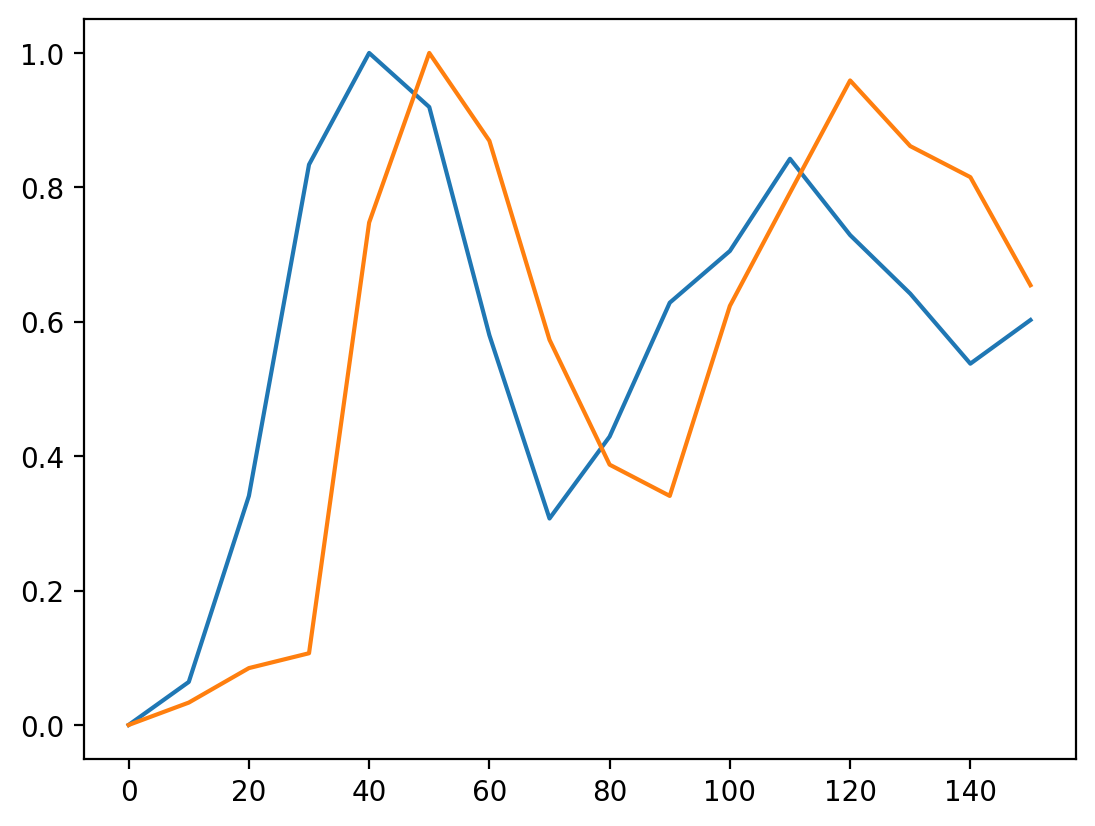

In [180]:
from src.sgd import get_orfname

early_bin = mnase_analysis_rep1.normalized_bin_curves.loc[get_orfname('VPS8')]
late_bin = mnase_analysis_rep1.normalized_bin_curves.loc[get_orfname('SSK22')]

plt.plot(early_bin)
plt.plot(late_bin)

In [175]:
from src.config import load_yl_rg1_vst_config

config = load_yl_rg1_vst_config(1)
from src.helpers import calcH
from src.global_config import GlobalConstants

H, _ = calcH(config.intervals_wt1, GlobalConstants.CHROM_WT1_TIMEPOINTS)

In [585]:
copy_num_rep1 = pd.read_csv(f'datasets/computed_mnase/dna_copy_scaling_rep1.csv').set_index("Unnamed: 0")
copy_num_rep1.head()

g = test_g#early_bin.values.reshape((-1, 1))*100000+1.

In [586]:
n_times = g.shape[0]
transition_point = cp.Variable(integer=True)

f_dg1_i = config.get_Hpositions_for_phase('DG1')
f_rg1_i = config.get_Hpositions_for_phase('RG1')
f_cg1_i = config.get_Hpositions_for_phase('CG1')
f_pg1_i = config.get_Hpositions_for_phase('postG1')

f_rg1 = np.zeros((len(f_dg1_i), 1)).astype(bool)
f_cg1 = np.zeros((len(f_dg1_i), 1)).astype(bool)
f_dg1 = np.zeros((len(f_dg1_i), 1)).astype(bool)
f_pg1 = cp.Variable((len(f_pg1_i), 1), boolean=True)
f_halted = np.zeros((1, 1)).astype(bool)

f = cp.vstack([f_rg1, f_cg1, f_dg1, f_pg1, f_halted])

# Define the objective function: minimize the l2 norm of H*f - g
objective = cp.Minimize(cp.norm(H@f - g))

constraints = [f_pg1 >= 0.]
                        
# Post G1
for i in range(1, len(f_pg1_i)):
    index = f_pg1_i[i]
    prev_index = f_pg1_i[i-1]
    constraints.append(f[index] >= f[prev_index])

problem = cp.Problem(objective, constraints)
problem.solve(verbose=False)

print("CVXPY problem finished with status: ", problem.status)
print("Transition point", (f.value > 0.5).argmax())

CVXPY problem finished with status:  optimal
Transition point 157


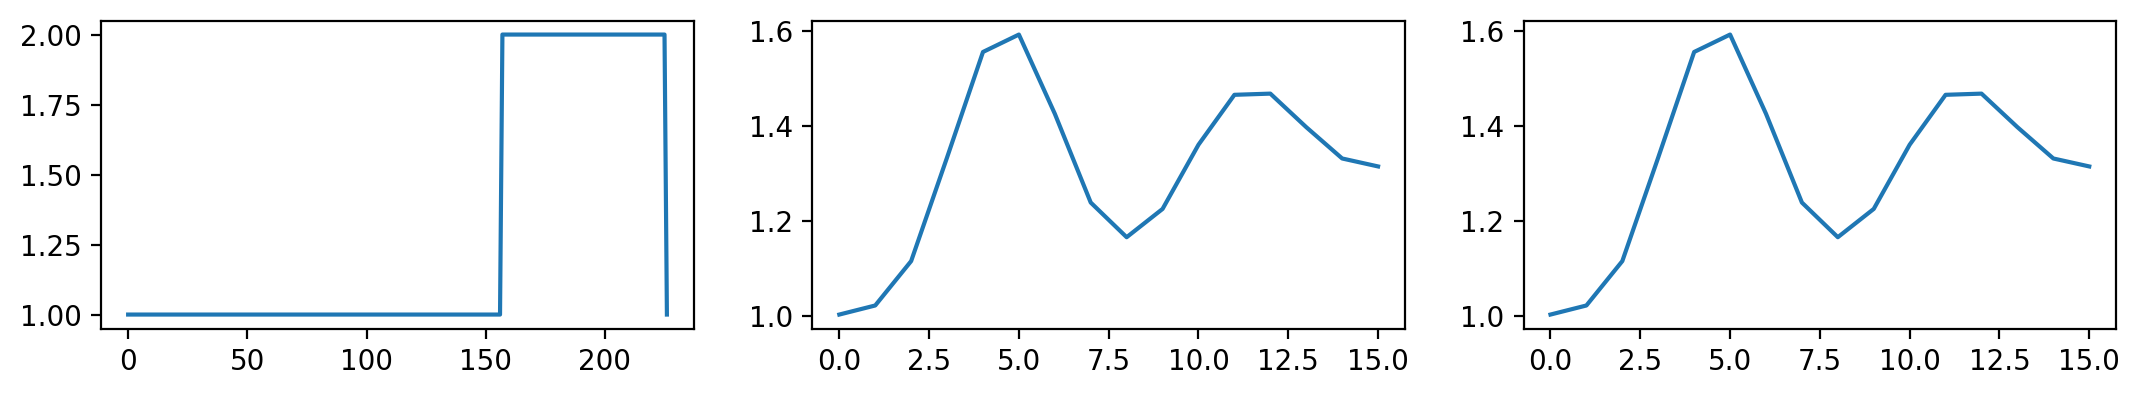

In [596]:
plt.figure(figsize=(13, 2))

plt.subplot(1, 3, 1)
plt.plot(f.value+1)

plt.subplot(1, 3, 2)
plt.plot((H@f.value)+1)

plt.subplot(1, 3, 3)
plt.plot(g+1)


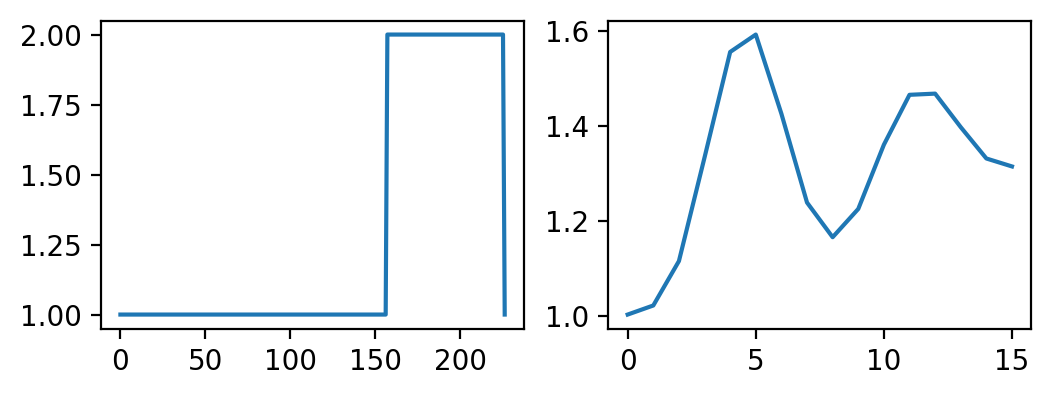

In [597]:
# Let's see what an example good predicted G looks like:
# Assume replication occurs at the start of S
f_test = np.zeros(f.shape)
f_test[f_pg1_i[10:]] = 1.0

plt.figure(figsize=(6, 2))

plt.subplot(1, 2, 1)
plt.plot(f_test+1)

test_g = (H@f_test)+1.
plt.subplot(1, 2, 2)
plt.plot(test_g)

# Why doesn't the model exactly find the test f I created?
# Are one of my constraints having an issue?
